# 05 Task 1: service time and late risk

**Purpose:** predict, for every planned stop, how long the handling will take (`pred_service_min`) and how likely the vehicle is to arrive after the window closes (`pred_late_prob`).

**Approach in one paragraph.** Lateness builds up along a route: a slow depot exit, slow roads and long stops earlier on all push back the later stops. So instead of guessing lateness stop by stop, we model the three things that cause it (depot delay, travel slowdown, service time) and replay each drafted route 1,000 times with the real timing rules. The share of runs that arrive after closing is the late risk. A direct LightGBM classifier is trained as a challenger, and the two are compared and blended on a holdout.

**Inputs:** `stops.parquet` and the reference tables; features come from `src/xora/features.py` (notebook 04).

**Outputs:**
- `submissions/submission_task1.csv`
- `models/route_simulator.pkl`, `models/late_classifier.pkl` and `models/manifest.json`

In [1]:
import json
import warnings

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

from xora import features as fe
from xora.io import load_processed
from xora.paths import MODELS, SUBMISSIONS, raw_file
from xora.plotting import apply_style, SERIES, INK, INK_SOFT
from xora.simulation import LGB_PARAMS, SEED, TRAVEL_FEATURES, DELAY_FEATURES, RouteSimulator, _fit_lgb

warnings.filterwarnings("ignore", category=UserWarning)
apply_style()
pd.set_option("display.width", 160)

stops = load_processed("stops")
tables = dict(outlets=load_processed("outlets"), vehicles=load_processed("vehicles"),
              allowance=load_processed("service_allowance"), calendar=load_processed("calendar"),
              road=load_processed("road_conditions"), traffic=load_processed("traffic_speed"))

def build_frame(stop_table):
    feats = fe.build_task1_features(stop_table, **tables)
    return fe.model_frame(stops, feats)

full = build_frame(stops)
FEATURES = [c for c in full.columns if c not in fe.FRAME_COLS]
print(f"{len(full):,} stops, {len(FEATURES)} features")

96,908 stops, 61 features


## 1. A holdout that looks like the test

The test stops (16 Feb to 28 Mar 2026) start right after training ends, and for them the newest history a planner has is from mid February. The holdout copies that situation:

| Window | Dates | Used for |
|---|---|---|
| fit | up to 15 Nov 2025 | training the models |
| validation | 16 Nov to 31 Dec 2025 | early stopping and learning the simulation noise |
| holdout | 1 Jan to 14 Feb 2026 | every number reported below |

For the holdout, features are rebuilt with every actual from 1 January onward hidden, so its history freezes at the end of December, exactly as the test's history freezes in February. Labels stay untouched for scoring.

In [2]:
VAL_START, HOLD_START = pd.Timestamp("2025-11-16"), pd.Timestamp("2026-01-01")

hidden = stops.copy()
hidden.loc[hidden.date >= HOLD_START, fe.ACTUAL_COLS] = np.nan
hold_frame = build_frame(hidden)
label_cols = ["actual_depart_time_min", "actual_travel_duration_min", "service_min", "late"]
hold_frame[label_cols] = full[label_cols]

train = full.split == "train"
fit = full[train & (full.date < VAL_START)]
val = full[train & (full.date >= VAL_START) & (full.date < HOLD_START)]
hold = hold_frame[train & (hold_frame.date >= HOLD_START)]
y_svc, y_late = hold.service_min.to_numpy(), hold.late.astype(int).to_numpy()

pd.DataFrame({w: [len(d), d.date.min().date(), d.date.max().date()] for w, d in
              [("fit", fit), ("validation", val), ("holdout", hold)]},
             index=["stops", "from", "to"]).T

,stops,from,to
fit,81133,2024-01-01,2025-11-15
validation,5300,2025-11-17,2025-12-31
holdout,5461,2026-01-01,2026-02-14


## 2. Baselines: how today's planning does

A model only matters if it beats what Waypoint already does.
- **Service time:** the published allowance table, and a smarter baseline that uses each outlet's own history.
- **Late risk:** the overall late rate, and a slack rule that gives each stop the historical late rate of its planned slack band.

In [3]:
def service_scores(pred, y=y_svc):
    err = pred - y
    return {"MAE": np.mean(np.abs(err)), "RMSE": np.sqrt(np.mean(err ** 2)), "bias": np.mean(err)}

def late_scores(p, y=y_late):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return {"log loss": log_loss(y, p), "Brier": brier_score_loss(y, p), "AUC": roc_auc_score(y, p)}

service_board = pd.DataFrame({
    "allowance table (today)": service_scores(hold.allowance_min.to_numpy()),
    "outlet history": service_scores(hold.outlet_hist_service_mean.fillna(hold.allowance_min).to_numpy()),
}).T

SLACK_BANDS = [-np.inf, 0, 15, 30, 60, 120, np.inf]
band_rate = fit.late.astype(float).groupby(pd.cut(fit.planned_slack_min, SLACK_BANDS), observed=True).mean()
late_board = pd.DataFrame({
    "overall late rate": late_scores(np.full(len(hold), fit.late.astype(float).mean())),
    "planned slack rule": late_scores(pd.cut(hold.planned_slack_min, SLACK_BANDS).map(band_rate).astype(float).to_numpy()),
}).T
display(service_board.round(2))
late_board.round(4)

,MAE,RMSE,bias
allowance table (today),7.09,11.67,-1.56
outlet history,5.51,8.89,0.58


,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573


The allowance table misses by about 7 minutes per stop on the holdout. Slack on paper already separates late from on-time stops quite well (AUC 0.86), which is the bar for the late models.

## 3. Service time: which loss to train on

The scoring metric for service time is not stated, so we don't guess. We train the same model three ways and keep the one that is safest whichever metric is used:
- **median** (L1 loss): best if scored on MAE
- **mean** (L2 loss): best if scored on RMSE
- **Huber**: a compromise between the two

For each, regret is how much worse it is than the best of the three on each metric. We keep the model with the smallest worst-case regret.

In [4]:
objectives = {"median": dict(objective="l1"), "mean": dict(objective="l2"),
              "Huber": dict(objective="huber", alpha=5.0)}
service_models, rows = {}, {}
for name, params in objectives.items():
    m = _fit_lgb(fit[FEATURES], fit.service_min, val[FEATURES], val.service_min, **params)
    service_models[name] = m
    rows[name] = service_scores(np.clip(m.predict(hold[FEATURES]), 1, None))

loss_table = pd.DataFrame(rows).T[["MAE", "RMSE", "bias"]]
for metric in ["MAE", "RMSE"]:
    loss_table[f"{metric} regret"] = loss_table[metric] / loss_table[metric].min() - 1
loss_table["worst regret"] = loss_table[["MAE regret", "RMSE regret"]].max(axis=1)
CHOSEN = loss_table["worst regret"].idxmin()
print("chosen:", CHOSEN)
loss_table.style.format({c: "{:.2%}" for c in loss_table.columns if "regret" in c} | {"MAE": "{:.3f}", "RMSE": "{:.3f}", "bias": "{:.3f}"})

chosen: mean


,MAE,RMSE,bias,MAE regret,RMSE regret,worst regret
median,3.900,6.510,-0.333,0.00%,3.32%,3.32%
mean,3.920,6.301,0.228,0.52%,0.00%,0.52%
Huber,3.915,6.629,-0.272,0.37%,5.20%,5.20%


All three cut the allowance table's error roughly in half. The median model wins MAE by a hair but gives up several percent on RMSE, because it ignores how long the slow stops run. The mean model is within half a percent of the best MAE and is best on RMSE, so it has the smallest worst-case regret and is the one we keep.

## 4. The other two components: travel and depot delay

- **Travel slowdown:** the log of actual over planned travel time for each leg, from district, hour, monsoon, road advisory, festival timing and leg length.
- **Depot delay:** how many minutes after the planned time the vehicle actually leaves, from depot, vehicle, start time, load and calendar.

Both are fitted inside the simulator alongside the chosen service model.

In [5]:
sim = RouteSimulator(service_features=FEATURES, service_objective=CHOSEN).fit(fit, val)

travel_true = np.log(hold.actual_travel_duration_min / hold.planned_travel_min.clip(lower=1))
travel_pred = sim.travel_model.predict(hold[sim.travel_features])
first = hold[hold.seq == 0]
delay_true = first.actual_depart_time_min - first.planned_depart_time_min
delay_pred = sim.delay_model.predict(first[sim.delay_features])

ratio_true, ratio_pred = np.exp(travel_true), np.exp(travel_pred)
pd.DataFrame({
    "travel ratio, MAE": [np.mean(np.abs(ratio_true - 1)), np.mean(np.abs(ratio_true - hold.district_hist_travel_ratio)), np.mean(np.abs(ratio_true - ratio_pred))],
    "depot delay, MAE (min)": [np.mean(np.abs(delay_true)), np.mean(np.abs(delay_true - first.vehicle_hist_depart_delay)), np.mean(np.abs(delay_true - delay_pred))],
}, index=["plan as given", "history average", "component model"]).round(3)

,"travel ratio, MAE","depot delay, MAE (min)"
plan as given,0.487,7.654
history average,0.339,4.468
component model,0.215,4.267


The plan assumes roads run at planned speed, and they almost never do. The travel model cuts the travel error well below both the plan and the district average. Depot delay is mostly random (a few minutes either way), so the model improves only a little on each vehicle's own average. That is fine: the simulation samples that randomness rather than pretending to predict it.

## 5. Route simulation

The simulator learns its noise from the validation window, which the models never trained on:
- **service:** the spread of actual over predicted, per brand
- **travel:** a shared part per route (a slow day slows every leg) plus a part per leg
- **depot delay:** its leftover spread

It then replays every holdout route 1,000 times.

In [6]:
sim.learn_noise(val)
sim_hold = sim.simulate(hold)
p_sim = sim_hold.sim_late_prob.to_numpy()
late_board.loc["route simulation"] = late_scores(p_sim)
late_board.round(4)

,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573
route simulation,0.1432,0.0429,0.9703


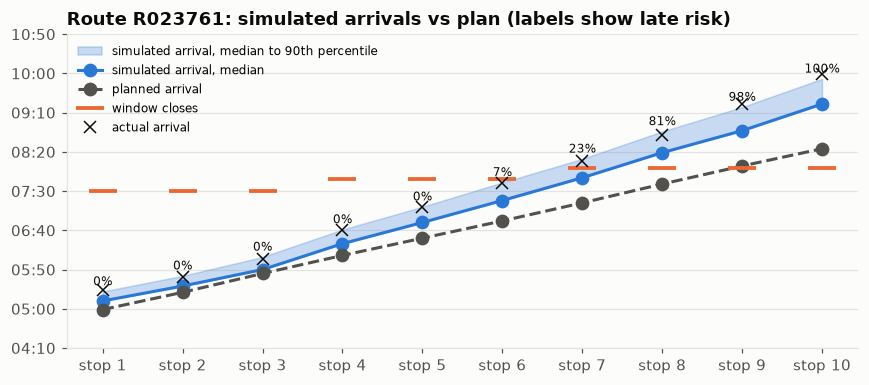

In [7]:
# One busy holdout route, stop by stop
rid = hold.groupby("route_id").size().sort_values().index[-1]
r = hold[hold.route_id == rid].sort_values("seq")
o = sim_hold.set_index("delivery_id").loc[r.delivery_id]
x = np.arange(len(r))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(x, o.arrival_p50_min, o.arrival_p90_min, color=SERIES[0], alpha=0.25, label="simulated arrival, median to 90th percentile")
ax.plot(x, o.arrival_p50_min, color=SERIES[0], marker="o", markersize=8, label="simulated arrival, median")
ax.plot(x, r.planned_arrival_min, color=INK_SOFT, linestyle="--", marker="o", markersize=8, label="planned arrival")
ax.plot(x, r.window_close_time_min, color=SERIES[1], marker="_", markersize=18, linestyle="none", markeredgewidth=2.5, label="window closes")
actual_arrival = r.actual_depart_time_min + r.actual_travel_duration_min
ax.plot(x, actual_arrival, color=INK, marker="x", markersize=8, linestyle="none", label="actual arrival")
for i, p in enumerate(o.sim_late_prob):
    ax.text(i, o.arrival_p90_min.iloc[i] + 8, f"{p:.0%}", ha="center", fontsize=8, color=INK)
ax.set_xticks(x, [f"stop {i + 1}" for i in x])
ax.set_yticks(ax.get_yticks(), [f"{int(t // 60):02d}:{int(t % 60):02d}" for t in ax.get_yticks()])
ax.set_title(f"Route {rid}: simulated arrivals vs plan (labels show late risk)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The planned arrivals (dashed) fall further behind reality at every stop. The simulated band follows the actual arrivals much more closely, which land inside it or just above it. The late risk rises along the route for the same reason real lateness does.

## 6. Challenger, blend and calibration

The challenger is a LightGBM classifier trained directly on the late label with the same features (including the history-corrected slack). We compare it with the simulation and with a plain 50/50 average of the two. An average needs no fitting, so it cannot overfit the holdout.

We also test isotonic calibration, cross-fitted on alternating holdout weeks so it is never scored on the weeks it learned from.

In [8]:
def fit_classifier(cols):
    return lgb.LGBMClassifier(n_estimators=4000, **LGB_PARAMS).fit(
        fit[cols], fit.late.astype(int), eval_X=(val[cols],), eval_y=(val.late.astype(int),),
        callbacks=[lgb.early_stopping(200, verbose=False)])

def blend(p_a, p_b):
    # Never fully certain: a 0 or 1 that turns out wrong costs too much under log loss
    return np.clip((p_a + p_b) / 2, 0.002, 0.998)

clf = fit_classifier(FEATURES)
p_clf = clf.predict_proba(hold[FEATURES])[:, 1]
p_blend = blend(p_sim, p_clf)
late_board.loc["direct classifier"] = late_scores(p_clf)
late_board.loc["blend (50/50)"] = late_scores(p_blend)

week_parity = hold.date.dt.isocalendar().week.to_numpy() % 2
def cross_fit_isotonic(p):
    out = np.empty_like(p)
    for k in (0, 1):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1 - 1e-4)
        iso.fit(p[week_parity != k], y_late[week_parity != k])
        out[week_parity == k] = iso.predict(p[week_parity == k])
    return out
late_board.loc["blend + isotonic"] = late_scores(cross_fit_isotonic(p_blend))
late_board.round(4)

,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573
route simulation,0.1432,0.0429,0.9703
direct classifier,0.1381,0.0429,0.9736
blend (50/50),0.1360,0.0415,0.9745
blend + isotonic,0.1379,0.0419,0.9729


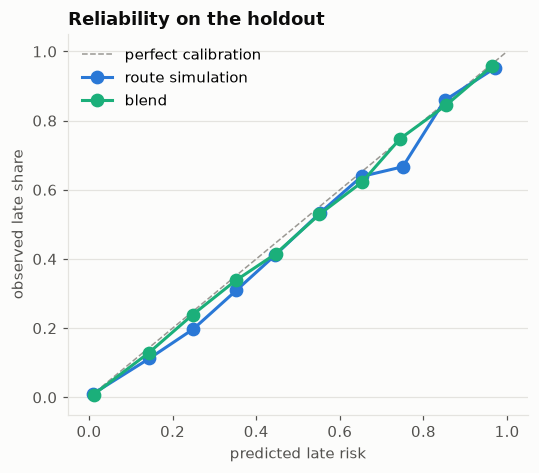

In [9]:
bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(5, 4.4))
ax.plot([0, 1], [0, 1], color="#9a9893", linestyle="--", linewidth=1, label="perfect calibration")
for (name, p), color in zip([("route simulation", p_sim), ("blend", p_blend)], [SERIES[0], SERIES[2]]):
    idx = np.digitize(p, bins[1:-1])
    rel = pd.DataFrame({"pred": p, "obs": y_late, "bin": idx}).groupby("bin").mean()
    ax.plot(rel.pred, rel.obs, marker="o", markersize=8, color=color, label=name)
ax.set_xlabel("predicted late risk")
ax.set_ylabel("observed late share")
ax.set_title("Reliability on the holdout")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

- The simulation alone beats the slack rule by a wide margin (log loss halves) and is well calibrated, without ever being trained on the late label.
- The classifier is slightly sharper, and the blend is best on every metric. Their errors differ enough that averaging helps.
- Isotonic calibration makes things slightly worse because the blend is already calibrated, so it is not used.

We submit the blend.